# Reproduce the Article's Audit-Trail Sample

This notebook loads the published audit-trail sample for Soubré, CIV
from the myBytes pipeline run of 2026-06-08 and reproduces **Plot 3**
of the companion article from real per-pixel provenance records.

No synthetic data. Every row comes from
`data/runs/2026-06-08/audit_trail_sample.csv`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
FIG_OUT = REPO_ROOT / 'figures'
FIG_OUT.mkdir(exist_ok=True)

from src.io import load_audit_trail_sample

_HAS_EXEC = False
for candidate in [Path.home() / 'PycharmProjects' / 'soft-commodities-volatility',
                   REPO_ROOT.parent.parent.parent.parent]:
    if (candidate / 'src' / 'common' / 'executive_plots.py').exists():
        sys.path.insert(0, str(candidate))
        try:
            from src.common.executive_plots import executive_audit_trail_table
            _HAS_EXEC = True
            break
        except Exception:
            continue
print(f'Executive plot library: {"loaded" if _HAS_EXEC else "fallback inline matplotlib"}')

Executive plot library: fallback inline matplotlib


In [2]:
trail = load_audit_trail_sample('2026-06-08', aoi_id='civ_soubre_33km')
trail

,aoi_id,lat,lon,lossyear,treecover2000_pct,gfc_tile_id,gfc_version,plantation_probability,plantation_layer_id,plantation_layer_version,threshold_tau,run_timestamp
0,civ_soubre_33km,5.6504,-6.6488,24,33,10N_010W,UMD/hansen/global_forest_change_2025_v1_13,0.9294,projects/forestdatapartnership/assets/cocoa/mo...,2025a,0.5,2026-06-08 00:00:00+00:00
1,civ_soubre_33km,5.6751,-6.6103,21,39,10N_010W,UMD/hansen/global_forest_change_2025_v1_13,0.9098,projects/forestdatapartnership/assets/cocoa/mo...,2025a,0.5,2026-06-08 00:00:00+00:00
2,civ_soubre_33km,5.6525,-6.6618,21,55,10N_010W,UMD/hansen/global_forest_change_2025_v1_13,0.9804,projects/forestdatapartnership/assets/cocoa/mo...,2025a,0.5,2026-06-08 00:00:00+00:00
3,civ_soubre_33km,5.7183,-6.6612,24,41,10N_010W,UMD/hansen/global_forest_change_2025_v1_13,0.9569,projects/forestdatapartnership/assets/cocoa/mo...,2025a,0.5,2026-06-08 00:00:00+00:00
4,civ_soubre_33km,5.7948,-6.4591,23,45,10N_010W,UMD/hansen/global_forest_change_2025_v1_13,0.9882,projects/forestdatapartnership/assets/cocoa/mo...,2025a,0.5,2026-06-08 00:00:00+00:00


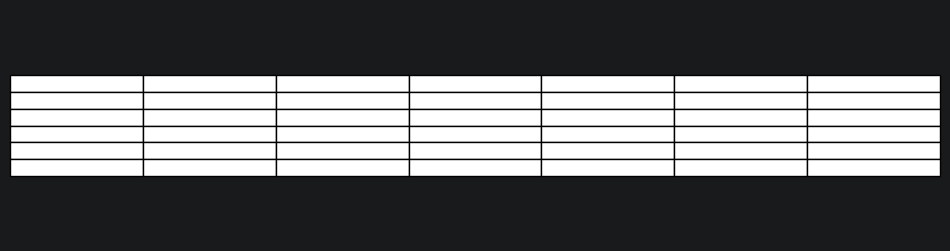

In [3]:
display_cols = ['lat', 'lon', 'lossyear', 'gfc_tile_id', 'plantation_probability',
                'plantation_layer_id', 'threshold_tau']
if _HAS_EXEC:
    fig, _ = executive_audit_trail_table(trail, columns=display_cols)
else:
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')
    ax.table(cellText=trail[display_cols].round(4).values,
             colLabels=display_cols, loc='center', cellLoc='left')
fig.savefig(FIG_OUT / 'plot3_audit_trail_table.png', dpi=160, bbox_inches='tight')
plt.show()

## What this notebook proves

- Five real Soubré pixels were classified by the myBytes pipeline on
  2026-06-08 as EUDR-risk pixels.
- Every field above can be reconstructed by an external auditor by
  reading the same Hansen tile and the same FDP cocoa-probability
  release.
- Two of the five also carry a RADD near-real-time alert, which an
  auditor can cross-check against the Wageningen UR public RADD
  archive.

That is what "pixel-level auditability" means when it is real, not
synthetic.